In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\SREENITHI\Downloads\Train_Test_Network_dataset\Train_Test_Network_dataset\train_test_network.csv")  # update path

print(df.shape)
print(df.columns)
df.head()

(211043, 44)
Index(['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service',
       'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes',
       'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query',
       'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA',
       'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed',
       'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth',
       'http_method', 'http_uri', 'http_version', 'http_request_body_len',
       'http_response_body_len', 'http_status_code', 'http_user_agent',
       'http_orig_mime_types', 'http_resp_mime_types', 'weird_name',
       'weird_addl', 'weird_notice', 'label', 'type'],
      dtype='object')


,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211043 entries, 0 to 211042
Data columns (total 44 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   src_ip                  211043 non-null  object 
 1   src_port                211043 non-null  int64  
 2   dst_ip                  211043 non-null  object 
 3   dst_port                211043 non-null  int64  
 4   proto                   211043 non-null  object 
 5   service                 211043 non-null  object 
 6   duration                211043 non-null  float64
 7   src_bytes               211043 non-null  int64  
 8   dst_bytes               211043 non-null  int64  
 9   conn_state              211043 non-null  object 
 10  missed_bytes            211043 non-null  int64  
 11  src_pkts                211043 non-null  int64  
 12  src_ip_bytes            211043 non-null  int64  
 13  dst_pkts                211043 non-null  int64  
 14  dst_ip_bytes        

In [3]:
from IPython.display import display
print("\n--- First 5 Rows ---")
display(df.head())


--- First 5 Rows ---


,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor


In [ ]:

print("\n--- Missing Values ---")
print(df.isnull().sum().sum())


--- Missing Values ---
0


In [ ]:

target_col = 'type'   
attack_counts = df[target_col].value_counts()
attack_percent = df[target_col].value_counts(normalize=True) * 100

attack_summary = pd.DataFrame({
    'Count': attack_counts,
    'Percentage (%)': attack_percent.round(2)
})

print("--- Attack Type Distribution (TON_IoT) ---")
print(attack_summary)

--- Attack Type Distribution (TON_IoT) ---
            Count  Percentage (%)
type                             
normal      50000           23.69
backdoor    20000            9.48
ddos        20000            9.48
dos         20000            9.48
injection   20000            9.48
password    20000            9.48
ransomware  20000            9.48
scanning    20000            9.48
xss         20000            9.48
mitm         1043            0.49


In [7]:
df.isnull().sum().sort_values(ascending=False)

src_ip                    0
src_port                  0
ssl_cipher                0
ssl_resumed               0
ssl_established           0
ssl_subject               0
ssl_issuer                0
http_trans_depth          0
http_method               0
http_uri                  0
http_version              0
http_request_body_len     0
http_response_body_len    0
http_status_code          0
http_user_agent           0
http_orig_mime_types      0
http_resp_mime_types      0
weird_name                0
weird_addl                0
weird_notice              0
label                     0
ssl_version               0
dns_rejected              0
dns_RA                    0
missed_bytes              0
dst_ip                    0
dst_port                  0
proto                     0
service                   0
duration                  0
src_bytes                 0
dst_bytes                 0
conn_state                0
src_pkts                  0
dns_RD                    0
src_ip_bytes        

In [ ]:

target_col = 'type'      # attack categories
protocol_col = 'proto'   # protocol column (check your dataset)

top_5_attacks = df[target_col].value_counts().head(5).index
df_filtered = df[df[target_col].isin(top_5_attacks)]

protocol_attack_counts = pd.crosstab(
    df_filtered[protocol_col],
    df_filtered[target_col]
)

protocol_attack_counts['Total'] = protocol_attack_counts.sum(axis=1)
protocol_attack_counts = protocol_attack_counts.sort_values(by='Total', ascending=False)

print("--- Top 5 Attack Types by Protocol (TON_IoT) ---")
print(protocol_attack_counts)

--- Top 5 Attack Types by Protocol (TON_IoT) ---
type   backdoor   ddos    dos  injection  normal  Total
proto                                                  
tcp       19990  14730  18520      19270   18203  90713
udp          10   5270   1480        730   31673  39163
icmp          0      0      0          0     124    124


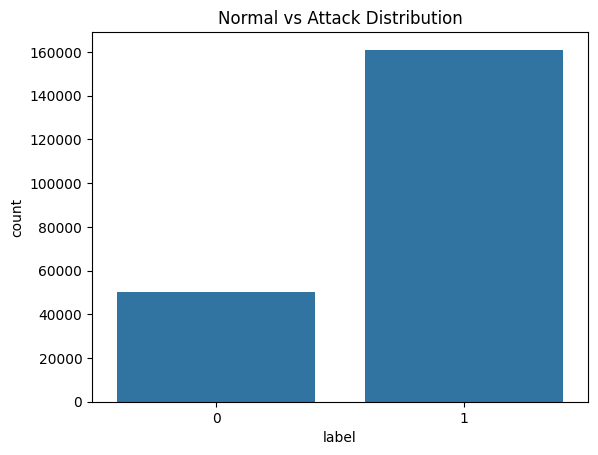

In [11]:
df['label'].value_counts()

sns.countplot(x='label', data=df)
plt.title("Normal vs Attack Distribution")
plt.show()